In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
import streamlit as st
import holidays as hdays


### CARGA DE ARCHIVOS

In [2]:
from pathlib import Path

# Desde la carpeta notebooks, subimos un nivel a la raíz del proyecto
base_dir = Path.cwd()
if base_dir.name == 'notebooks':
    data_dir = base_dir.parent / 'data' / 'raw' / 'entrenamiento'
else:
    data_dir = base_dir / 'data' / 'raw' / 'entrenamiento'

data_dir = data_dir.resolve()

ventas_path = data_dir / 'ventas.csv'
competencia_path = data_dir / 'competencia.csv'

df_ventas = pd.read_csv(ventas_path)
df_competencia = pd.read_csv(competencia_path)

df_ventas.head()

#print(f'DataFrame ventas: {df_ventas.shape}')
#print(f'DataFrame competencia: {df_competencia.shape}')
#print(df_ventas.head())
#print(df_competencia.head())

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


In [3]:
df_competencia.head()

,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [4]:
df_ventas.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos'],
      dtype='object')

In [5]:
df_competencia.columns

Index(['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage'], dtype='object')

## AHORA VEMOS CALIDAD DE LOS DATOS

In [6]:
from IPython.display import display

if not isinstance(df_ventas, pd.DataFrame):
    raise TypeError("df_ventas debe ser un pandas.DataFrame")

n_filas, n_columnas = df_ventas.shape
nulos_por_columna = df_ventas.isna().sum()
duplicados_columnas = df_ventas.columns[df_ventas.columns.duplicated()].tolist()
duplicados_filas = int(df_ventas.duplicated().sum())
numericas = df_ventas.select_dtypes(include=np.number).columns
infinitos_por_columna = pd.Series(0, index=df_ventas.columns, dtype="int64")
if len(numericas) > 0:
    infinitos_por_columna.loc[numericas] = np.isinf(df_ventas[numericas]).sum().astype("int64")

calidad_columnas = pd.DataFrame({
    "tipo": df_ventas.dtypes.astype(str),
    "no_nulos": df_ventas.notna().sum(),
    "nulos": nulos_por_columna,
    "porcentaje_nulos": (nulos_por_columna / n_filas * 100).round(2),
    "valores_unicos": df_ventas.nunique(dropna=True),
    "infinitos": infinitos_por_columna,
})
calidad_columnas["constante"] = calidad_columnas["valores_unicos"].eq(1)

fecha_parseada = pd.to_datetime(df_ventas["fecha"], errors="coerce") if "fecha" in df_ventas else pd.Series(dtype="datetime64[ns]")
fechas_invalidas = int(fecha_parseada.isna().sum())
columnas_numericas_negativas = {
    columna: int((df_ventas[columna] < 0).sum())
    for columna in numericas
    if (df_ventas[columna] < 0).any()
}
clave_duplicada = int(df_ventas.duplicated(subset=["fecha", "producto_id"]).sum()) if {"fecha", "producto_id"}.issubset(df_ventas.columns) else None
inconsistencias_ingresos = None
if {"ingresos", "precio_venta", "unidades_vendidas"}.issubset(df_ventas.columns):
    ingresos_calculados = (df_ventas["precio_venta"] * df_ventas["unidades_vendidas"]).round(2)
    inconsistencias_ingresos = int((df_ventas["ingresos"].round(2) != ingresos_calculados).sum())

resumen = pd.Series({
    "filas": n_filas,
    "columnas": n_columnas,
    "memoria_mb": round(df_ventas.memory_usage(deep=True).sum() / 1024**2, 3),
    "filas_duplicadas": duplicados_filas,
    "columnas_duplicadas": len(duplicados_columnas),
    "columnas_con_nulos": int(nulos_por_columna.gt(0).sum()),
    "nulos_totales": int(nulos_por_columna.sum()),
    "infinitos_totales": int(infinitos_por_columna.sum()),
    "columnas_constantes": int(calidad_columnas["constante"].sum()),
    "fechas_invalidas": fechas_invalidas,
    "duplicados_fecha_producto": clave_duplicada,
    "inconsistencias_ingresos": inconsistencias_ingresos,
})

print("INFORME FINAL DE CALIDAD DE DATOS: df_ventas")
print("=" * 52)
display(resumen.to_frame("valor"))

print("\n1. TIPOS, COMPLETITUD, CARDINALIDAD E INFINITOS")
display(calidad_columnas)

print("\n2. DESCRIPTIVOS NUMERICOS")
if len(numericas) > 0:
    display(df_ventas[numericas].describe().T)
else:
    print("No hay columnas numericas.")

categoricas = df_ventas.select_dtypes(exclude=np.number).columns
print("\n3. DESCRIPTIVOS CATEGORICOS / TEXTO")
if len(categoricas) > 0:
    descriptivos_categoricos = df_ventas[categoricas].describe().T
    descriptivos_categoricos["porcentaje_valor_mas_frecuente"] = [
        round(df_ventas[col].value_counts(normalize=True, dropna=False).iloc[0] * 100, 2)
        if len(df_ventas[col].value_counts(dropna=False)) > 0 else 0
        for col in categoricas
    ]
    display(descriptivos_categoricos)
else:
    print("No hay columnas categoricas o de texto.")

print("\n4. DUPLICADOS Y REGLAS DE CONSISTENCIA")
print(f"Filas duplicadas: {duplicados_filas} ({duplicados_filas / n_filas * 100:.2f}%)")
print(f"Columnas duplicadas: {duplicados_columnas if duplicados_columnas else 'ninguna'}")
print(f"Fechas no interpretables: {fechas_invalidas}")
print(f"Duplicados de la clave fecha-producto: {clave_duplicada if clave_duplicada is not None else 'no evaluado'}")
print(f"Ingresos distintos de precio_venta x unidades_vendidas: {inconsistencias_ingresos if inconsistencias_ingresos is not None else 'no evaluado'}")
print(f"Negativos por columna numerica: {columnas_numericas_negativas if columnas_numericas_negativas else 'ninguno'}")

print("\n5. DICTAMEN")
alertas = []
if nulos_por_columna.sum() > 0:
    alertas.append(f"{int(nulos_por_columna.sum())} valores nulos")
if duplicados_filas > 0:
    alertas.append(f"{duplicados_filas} filas duplicadas")
if len(duplicados_columnas) > 0:
    alertas.append(f"{len(duplicados_columnas)} nombres de columna duplicados")
if infinitos_por_columna.sum() > 0:
    alertas.append(f"{int(infinitos_por_columna.sum())} valores infinitos")
if calidad_columnas["constante"].sum() > 0:
    alertas.append(f"{int(calidad_columnas['constante'].sum())} columnas constantes")
if fechas_invalidas > 0:
    alertas.append(f"{fechas_invalidas} fechas no interpretables")
if clave_duplicada:
    alertas.append(f"{clave_duplicada} claves fecha-producto duplicadas")
if inconsistencias_ingresos:
    alertas.append(f"{inconsistencias_ingresos} ingresos inconsistentes")
if columnas_numericas_negativas:
    alertas.append("valores negativos en columnas numericas")

if alertas:
    print("REVISAR: " + "; ".join(alertas) + ".")
else:
    print("APROBADO: no se detectaron problemas estructurales, de completitud o consistencia basica.")

print("\nColumnas con incidencias:")
incidencias = calidad_columnas[
    calidad_columnas["nulos"].gt(0)
    | calidad_columnas["infinitos"].gt(0)
    | calidad_columnas["constante"]
]
display(incidencias if not incidencias.empty else pd.DataFrame({"resultado": ["ninguna"]}))

INFORME FINAL DE CALIDAD DE DATOS: df_ventas


,valor
filas,3552.000
columnas,10.000
memoria_mb,1.179
filas_duplicadas,0.000
columnas_duplicadas,0.000
columnas_con_nulos,0.000
nulos_totales,0.000
infinitos_totales,0.000
columnas_constantes,0.000
fechas_invalidas,0.000



1. TIPOS, COMPLETITUD, CARDINALIDAD E INFINITOS


,tipo,no_nulos,nulos,porcentaje_nulos,valores_unicos,infinitos,constante
fecha,object,3552,0,0.0,148,0,False
producto_id,object,3552,0,0.0,24,0,False
nombre,object,3552,0,0.0,24,0,False
categoria,object,3552,0,0.0,4,0,False
subcategoria,object,3552,0,0.0,16,0,False
precio_base,int64,3552,0,0.0,21,0,False
es_estrella,bool,3552,0,0.0,2,0,False
unidades_vendidas,int64,3552,0,0.0,52,0,False
precio_venta,float64,3552,0,0.0,2537,0,False
ingresos,float64,3552,0,0.0,3033,0,False



2. DESCRIPTIVOS NUMERICOS


,count,mean,std,min,25%,50%,75%,max
precio_base,3552.0,123.125000,165.576753,20.00,48.7500,72.50,118.7500,830.00
unidades_vendidas,3552.0,4.878660,6.311020,1.00,2.0000,3.00,5.0000,85.00
precio_venta,3552.0,121.816546,164.017963,19.00,47.2125,71.81,118.2200,854.22
ingresos,3552.0,605.972323,1079.071192,19.46,131.5350,216.57,639.6375,14508.40



3. DESCRIPTIVOS CATEGORICOS / TEXTO


,count,unique,top,freq,porcentaje_valor_mas_frecuente
fecha,3552,148,2021-10-25,24,0.68
producto_id,3552,24,PROD_001,148,4.17
nombre,3552,24,Nike Air Zoom Pegasus 40,148,4.17
categoria,3552,4,Running,1184,33.33
subcategoria,3552,16,Zapatillas Running,888,25.00
es_estrella,3552,2,False,2516,70.83



4. DUPLICADOS Y REGLAS DE CONSISTENCIA
Filas duplicadas: 0 (0.00%)
Columnas duplicadas: ninguna
Fechas no interpretables: 0
Duplicados de la clave fecha-producto: 0
Ingresos distintos de precio_venta x unidades_vendidas: 0
Negativos por columna numerica: ninguno

5. DICTAMEN
APROBADO: no se detectaron problemas estructurales, de completitud o consistencia basica.

Columnas con incidencias:


,resultado
0,ninguna


## CALIDAD DE DATOS DE df_competencia

In [7]:
if not isinstance(df_competencia, pd.DataFrame):
    raise TypeError("df_competencia debe ser un pandas.DataFrame")

n_filas_comp, n_columnas_comp = df_competencia.shape
nulos_comp = df_competencia.isna().sum()
duplicados_columnas_comp = df_competencia.columns[df_competencia.columns.duplicated()].tolist()
duplicados_filas_comp = int(df_competencia.duplicated().sum())
numericas_comp = df_competencia.select_dtypes(include=np.number).columns
infinitos_comp = pd.Series(0, index=df_competencia.columns, dtype="int64")
if len(numericas_comp) > 0:
    infinitos_comp.loc[numericas_comp] = np.isinf(df_competencia[numericas_comp]).sum().astype("int64")

calidad_comp = pd.DataFrame({
    "tipo": df_competencia.dtypes.astype(str),
    "no_nulos": df_competencia.notna().sum(),
    "nulos": nulos_comp,
    "porcentaje_nulos": (nulos_comp / n_filas_comp * 100).round(2),
    "valores_unicos": df_competencia.nunique(dropna=True),
    "infinitos": infinitos_comp,
})
calidad_comp["constante"] = calidad_comp["valores_unicos"].eq(1)

fecha_comp = pd.to_datetime(df_competencia["fecha"], errors="coerce") if "fecha" in df_competencia else pd.Series(dtype="datetime64[ns]")
fechas_invalidas_comp = int(fecha_comp.isna().sum())
negativos_comp = {
    columna: int((df_competencia[columna] < 0).sum())
    for columna in numericas_comp
    if (df_competencia[columna] < 0).any()
}
clave_duplicada_comp = (
    int(df_competencia.duplicated(subset=["fecha", "producto_id"]).sum())
    if {"fecha", "producto_id"}.issubset(df_competencia.columns)
    else None
)

resumen_comp = pd.Series({
    "filas": n_filas_comp,
    "columnas": n_columnas_comp,
    "memoria_mb": round(df_competencia.memory_usage(deep=True).sum() / 1024**2, 3),
    "filas_duplicadas": duplicados_filas_comp,
    "columnas_duplicadas": len(duplicados_columnas_comp),
    "columnas_con_nulos": int(nulos_comp.gt(0).sum()),
    "nulos_totales": int(nulos_comp.sum()),
    "infinitos_totales": int(infinitos_comp.sum()),
    "columnas_constantes": int(calidad_comp["constante"].sum()),
    "fechas_invalidas": fechas_invalidas_comp,
    "duplicados_fecha_producto": clave_duplicada_comp,
})

print("INFORME FINAL DE CALIDAD DE DATOS: df_competencia")
print("=" * 57)
display(resumen_comp.to_frame("valor"))

print("\n1. TIPOS, COMPLETITUD, CARDINALIDAD E INFINITOS")
display(calidad_comp)

print("\n2. DESCRIPTIVOS NUMERICOS")
if len(numericas_comp) > 0:
    display(df_competencia[numericas_comp].describe().T)
else:
    print("No hay columnas numericas.")

categoricas_comp = df_competencia.select_dtypes(exclude=np.number).columns
print("\n3. DESCRIPTIVOS CATEGORICOS / TEXTO")
if len(categoricas_comp) > 0:
    descriptivos_cat_comp = df_competencia[categoricas_comp].describe().T
    descriptivos_cat_comp["porcentaje_valor_mas_frecuente"] = [
        round(df_competencia[col].value_counts(normalize=True, dropna=False).iloc[0] * 100, 2)
        if len(df_competencia[col].value_counts(dropna=False)) > 0 else 0
        for col in categoricas_comp
    ]
    display(descriptivos_cat_comp)
else:
    print("No hay columnas categoricas o de texto.")

print("\n4. DUPLICADOS Y REGLAS DE CONSISTENCIA")
print(f"Filas duplicadas: {duplicados_filas_comp} ({duplicados_filas_comp / n_filas_comp * 100:.2f}%)")
print(f"Columnas duplicadas: {duplicados_columnas_comp if duplicados_columnas_comp else 'ninguna'}")
print(f"Fechas no interpretables: {fechas_invalidas_comp}")
print(f"Duplicados de la clave fecha-producto: {clave_duplicada_comp if clave_duplicada_comp is not None else 'no evaluado'}")
print(f"Negativos por columna numerica: {negativos_comp if negativos_comp else 'ninguno'}")

print("\n5. DICTAMEN")
alertas_comp = []
if nulos_comp.sum() > 0:
    alertas_comp.append(f"{int(nulos_comp.sum())} valores nulos")
if duplicados_filas_comp > 0:
    alertas_comp.append(f"{duplicados_filas_comp} filas duplicadas")
if len(duplicados_columnas_comp) > 0:
    alertas_comp.append(f"{len(duplicados_columnas_comp)} nombres de columna duplicados")
if infinitos_comp.sum() > 0:
    alertas_comp.append(f"{int(infinitos_comp.sum())} valores infinitos")
if calidad_comp["constante"].sum() > 0:
    alertas_comp.append(f"{int(calidad_comp['constante'].sum())} columnas constantes")
if fechas_invalidas_comp > 0:
    alertas_comp.append(f"{fechas_invalidas_comp} fechas no interpretables")
if clave_duplicada_comp:
    alertas_comp.append(f"{clave_duplicada_comp} claves fecha-producto duplicadas")
if negativos_comp:
    alertas_comp.append("valores negativos en precios")

if alertas_comp:
    print("REVISAR: " + "; ".join(alertas_comp) + ".")
else:
    print("APROBADO: no se detectaron problemas estructurales, de completitud o consistencia basica.")

print("\nColumnas con incidencias:")
incidencias_comp = calidad_comp[
    calidad_comp["nulos"].gt(0)
    | calidad_comp["infinitos"].gt(0)
    | calidad_comp["constante"]
]
display(incidencias_comp if not incidencias_comp.empty else pd.DataFrame({"resultado": ["ninguna"]}))

INFORME FINAL DE CALIDAD DE DATOS: df_competencia


,valor
filas,3552.000
columnas,5.000
memoria_mb,0.474
filas_duplicadas,0.000
columnas_duplicadas,0.000
columnas_con_nulos,0.000
nulos_totales,0.000
infinitos_totales,0.000
columnas_constantes,0.000
fechas_invalidas,0.000



1. TIPOS, COMPLETITUD, CARDINALIDAD E INFINITOS


,tipo,no_nulos,nulos,porcentaje_nulos,valores_unicos,infinitos,constante
fecha,object,3552,0,0.0,148,0,False
producto_id,object,3552,0,0.0,24,0,False
Amazon,float64,3552,0,0.0,3125,0,False
Decathlon,float64,3552,0,0.0,3001,0,False
Deporvillage,float64,3552,0,0.0,3105,0,False



2. DESCRIPTIVOS NUMERICOS


,count,mean,std,min,25%,50%,75%,max
Amazon,3552.0,118.623407,156.095628,16.85,47.1175,73.180,114.3425,858.3500
Decathlon,3552.0,111.412182,148.508132,15.45,43.2850,66.285,111.1725,867.3375
Deporvillage,3552.0,118.894628,160.216448,16.77,47.3100,72.700,114.9850,932.3250



3. DESCRIPTIVOS CATEGORICOS / TEXTO


,count,unique,top,freq,porcentaje_valor_mas_frecuente
fecha,3552,148,2021-10-25,24,0.68
producto_id,3552,24,PROD_001,148,4.17



4. DUPLICADOS Y REGLAS DE CONSISTENCIA
Filas duplicadas: 0 (0.00%)
Columnas duplicadas: ninguna
Fechas no interpretables: 0
Duplicados de la clave fecha-producto: 0
Negativos por columna numerica: ninguno

5. DICTAMEN
APROBADO: no se detectaron problemas estructurales, de completitud o consistencia basica.

Columnas con incidencias:


,resultado
0,ninguna


In [8]:
df_ventas["fecha"] = pd.to_datetime(df_ventas["fecha"])
df_competencia["fecha"] = pd.to_datetime(df_competencia["fecha"])

df_ventas = df_ventas.sort_values(["producto_id", "fecha"])
df_competencia = df_competencia.sort_values(["producto_id", "fecha"])

In [9]:
print("Tipo de datos de df_ventas:", df_ventas["fecha"].dtype)

Tipo de datos de df_ventas: datetime64[ns]


In [10]:
print("Tipo de datos de df_competencia:", df_competencia["fecha"].dtype)

Tipo de datos de df_competencia: datetime64[ns]


## Integrar los dataframes
### Se los va a cruzar por fecha y por producto

In [11]:
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 281.0+ KB


In [12]:
df_competencia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[ns]
 1   producto_id   3552 non-null   object        
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 166.5+ KB


In [13]:
df = pd.merge(
    df_ventas,
    df_competencia,
    how="inner",
    on=["fecha", "producto_id"]
)

print(df.head())

       fecha producto_id                    nombre categoria  \
0 2021-10-25    PROD_001  Nike Air Zoom Pegasus 40   Running   
1 2021-10-26    PROD_001  Nike Air Zoom Pegasus 40   Running   
2 2021-10-27    PROD_001  Nike Air Zoom Pegasus 40   Running   
3 2021-10-28    PROD_001  Nike Air Zoom Pegasus 40   Running   
4 2021-10-29    PROD_001  Nike Air Zoom Pegasus 40   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          115         True                  8   
2  Zapatillas Running          115         True                  8   
3  Zapatillas Running          115         True                  7   
4  Zapatillas Running          115         True                 12   

   precio_venta  ingresos  Amazon  Decathlon  Deporvillage  
0        118.36    710.16   82.96     111.88         97.43  
1        117.37    938.96   84.25     110.88         94.66  
2        11

In [14]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-26,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,8,117.37,938.96,84.25,110.88,94.66
2,2021-10-27,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,8,114.27,914.16,84.06,108.90,96.89
3,2021-10-28,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,118.14,826.98,81.98,109.87,96.08
4,2021-10-29,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,12,117.23,1406.76,83.84,110.32,94.48


## FASE 2: ANÁLISIS EXPLORATORIO DE DATOS
A continuación se presentan diferentes análisis y visualizaciones para entender el comportamiento de las ventas y la competencia.

In [15]:
# Preparación general del análisis exploratorio
import calendar

sns.set_theme(style="whitegrid", context="notebook")

df_eda = df.copy()
df_eda["fecha"] = pd.to_datetime(df_eda["fecha"], errors="coerce")
df_eda = df_eda.dropna(subset=["fecha"]).copy()
df_eda["año"] = df_eda["fecha"].dt.year
df_eda["dia_semana"] = df_eda["fecha"].dt.day_name()

orden_dias = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
]
nombres_dias = {
    "Monday": "Lunes", "Tuesday": "Martes", "Wednesday": "Miercoles",
    "Thursday": "Jueves", "Friday": "Viernes", "Saturday": "Sabado",
    "Sunday": "Domingo"
}
df_eda["dia_semana_es"] = df_eda["dia_semana"].map(nombres_dias)

print(f"Filas analizadas: {len(df_eda):,}")
print(f"Periodo: {df_eda['fecha'].min().date()} a {df_eda['fecha'].max().date()}")
print(f"Años disponibles: {sorted(df_eda['año'].unique())}")
display(df_eda.describe(include="all").T)


Filas analizadas: 3,552
Periodo: 2021-10-25 a 2024-11-30
Años disponibles: [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
fecha,3552,NaN,NaN,NaN,2023-05-13 17:59:59.999999744,2021-10-25 00:00:00,2022-08-03 18:00:00,2023-05-13 12:00:00,2024-02-20 12:00:00,2024-11-30 00:00:00,NaN
producto_id,3552,24,PROD_001,148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre,3552,24,Nike Air Zoom Pegasus 40,148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categoria,3552,4,Running,1184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subcategoria,3552,16,Zapatillas Running,888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precio_base,3552.0,NaN,NaN,NaN,123.125,20.0,48.75,72.5,118.75,830.0,165.576753
es_estrella,3552,2,False,2516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unidades_vendidas,3552.0,NaN,NaN,NaN,4.87866,1.0,2.0,3.0,5.0,85.0,6.31102
precio_venta,3552.0,NaN,NaN,NaN,121.816546,19.0,47.2125,71.81,118.22,854.22,164.017963
ingresos,3552.0,NaN,NaN,NaN,605.972323,19.46,131.535,216.57,639.6375,14508.4,1079.071192


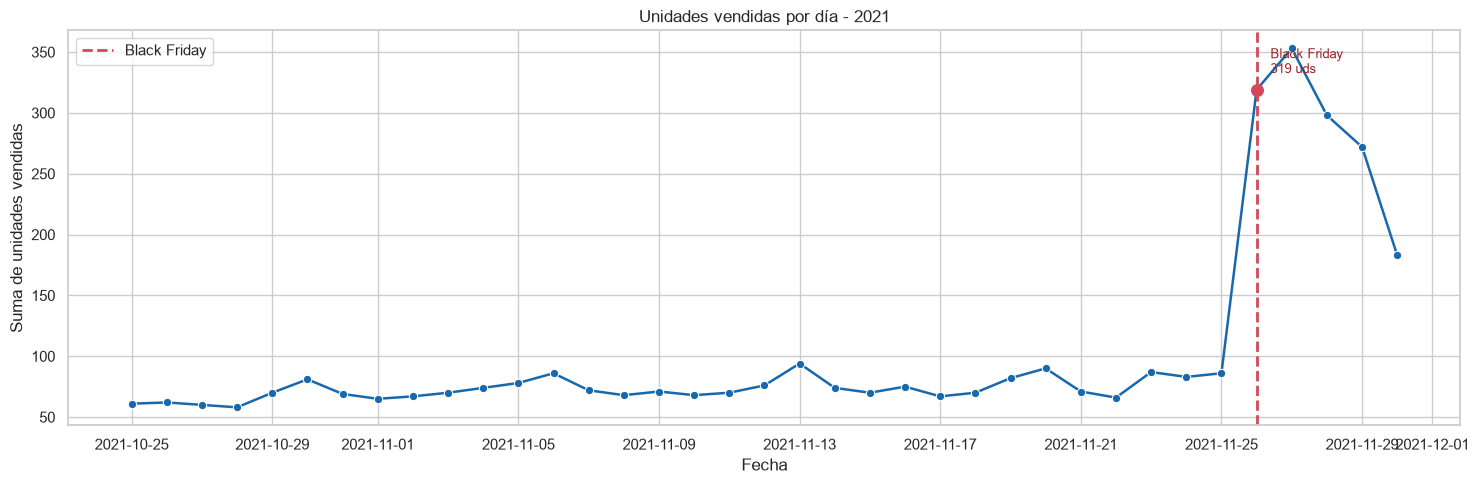

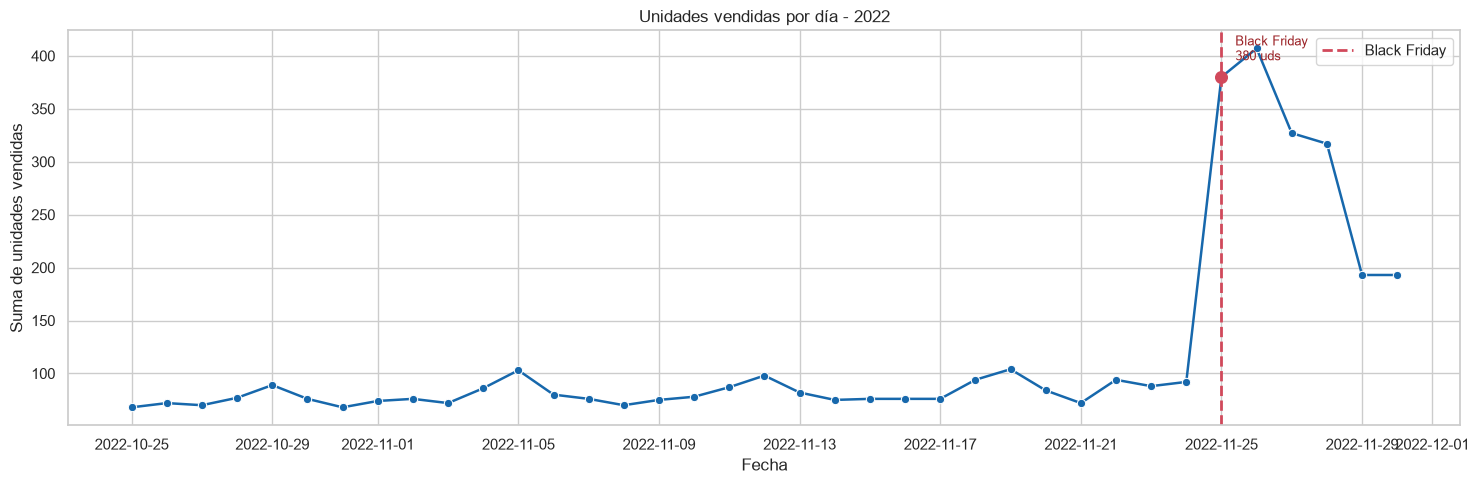

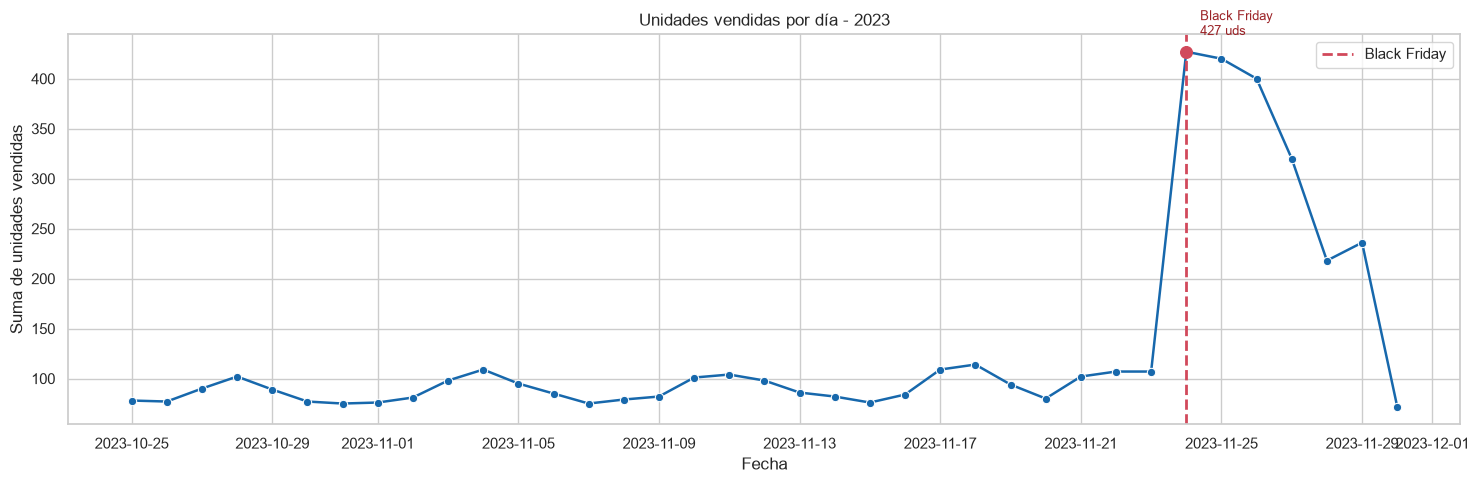

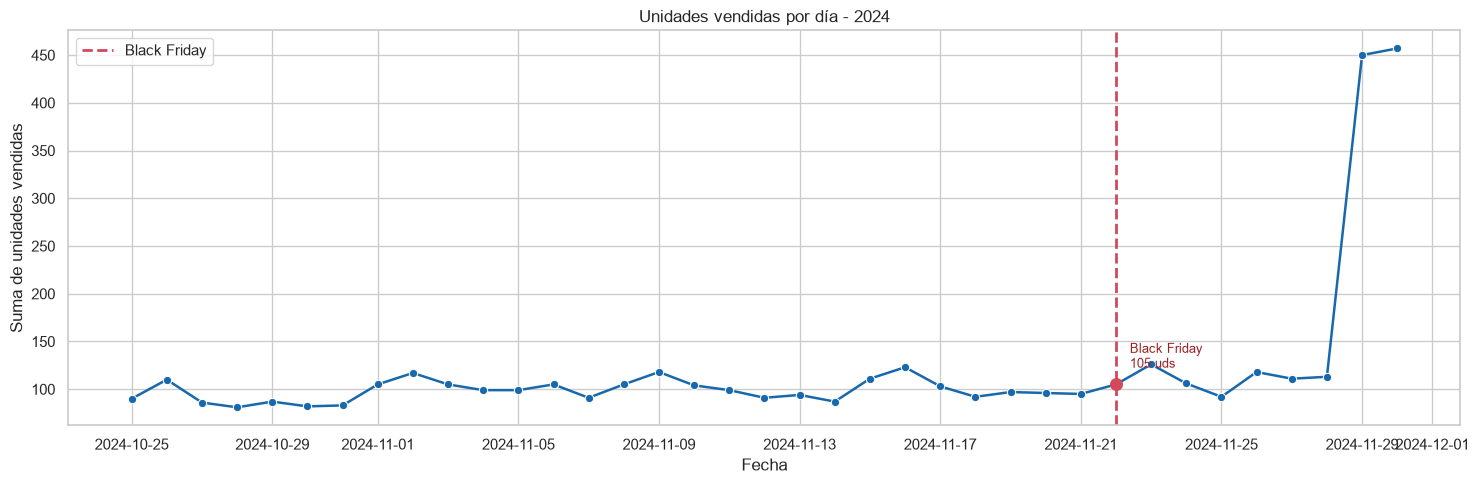

In [16]:
# Gráfico 1: ventas temporales por año
for año in sorted(df_eda["año"].unique()):
    datos_año = (
        df_eda.loc[df_eda["año"] == año]
        .groupby("fecha", as_index=False)["unidades_vendidas"]
        .sum()
        .sort_values("fecha")
    )

    viernes_noviembre = [
        fecha for fecha in pd.date_range(f"{año}-11-01", f"{año}-11-30", freq="D")
        if fecha.weekday() == 4
    ]
    black_friday = viernes_noviembre[3] if len(viernes_noviembre) >= 4 else None

    fig, ax = plt.subplots(figsize=(15, 5))
    sns.lineplot(
        data=datos_año,
        x="fecha",
        y="unidades_vendidas",
        marker="o",
        linewidth=1.8,
        color="#1768ac",
        ax=ax,
    )
    if black_friday is not None and datos_año["fecha"].min() <= black_friday <= datos_año["fecha"].max():
        ax.axvline(black_friday, color="#d1495b", linestyle="--", linewidth=2, label="Black Friday")
        valor_bf = datos_año.loc[datos_año["fecha"] == black_friday, "unidades_vendidas"]
        if not valor_bf.empty:
            ax.scatter(black_friday, valor_bf.iloc[0], color="#d1495b", s=70, zorder=4)
            ax.annotate(
                f"Black Friday\n{int(valor_bf.iloc[0]):,} uds",
                xy=(black_friday, valor_bf.iloc[0]),
                xytext=(10, 12),
                textcoords="offset points",
                color="#9b2226",
                fontsize=9,
            )
        ax.legend()
    ax.set_title(f"Unidades vendidas por día - {año}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Suma de unidades vendidas")
    plt.tight_layout()
    plt.show()


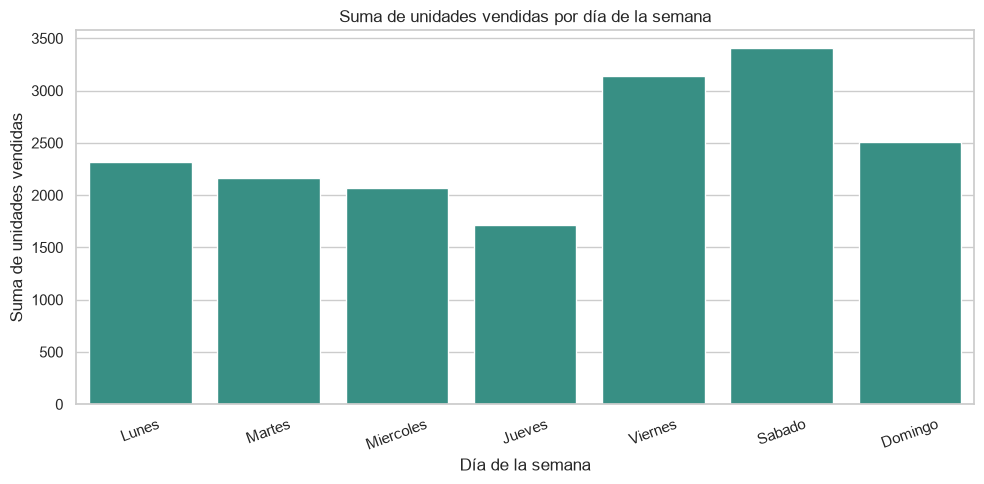

,dia_semana_es,unidades_vendidas
1,Lunes,2321
5,Martes,2164
6,Miercoles,2068
4,Jueves,1718
0,Viernes,3140
2,Sabado,3405
3,Domingo,2513


In [17]:
# Gráfico 2: ventas por día de la semana
ventas_dia = (
    df_eda.groupby(["dia_semana", "dia_semana_es"], as_index=False)["unidades_vendidas"]
    .sum()
)
ventas_dia["orden"] = ventas_dia["dia_semana"].map({dia: i for i, dia in enumerate(orden_dias)})
ventas_dia = ventas_dia.sort_values("orden")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=ventas_dia,
    x="dia_semana_es",
    y="unidades_vendidas",
    color="#2a9d8f",
    order=[nombres_dias[dia] for dia in orden_dias],
    ax=ax,
)
ax.set_title("Suma de unidades vendidas por día de la semana")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Suma de unidades vendidas")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

display(ventas_dia[["dia_semana_es", "unidades_vendidas"]])


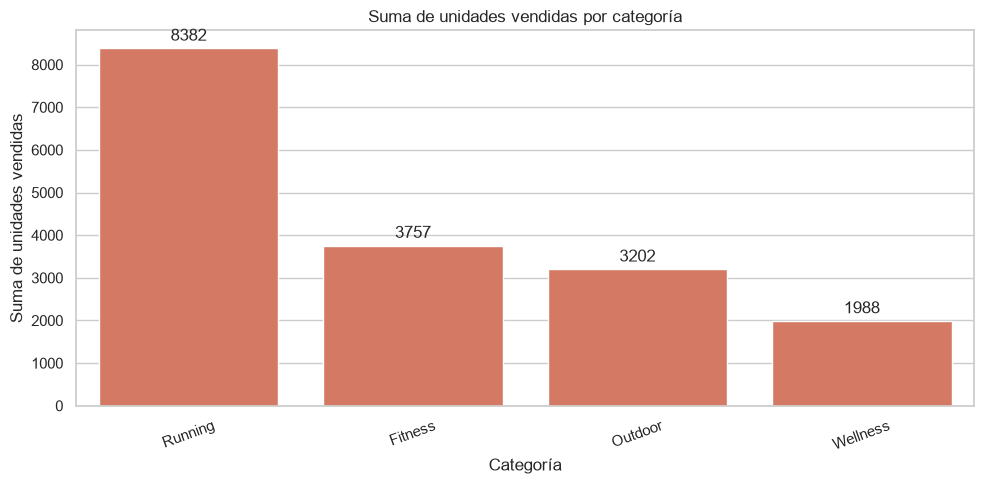

,categoria,unidades_vendidas
2,Running,8382
0,Fitness,3757
1,Outdoor,3202
3,Wellness,1988


In [18]:
# Gráfico 3: ventas por categoría
ventas_categoria = (
    df_eda.groupby("categoria", as_index=False)["unidades_vendidas"]
    .sum()
    .sort_values("unidades_vendidas", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=ventas_categoria,
    x="categoria",
    y="unidades_vendidas",
    color="#e76f51",
    ax=ax,
)
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)
ax.set_title("Suma de unidades vendidas por categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Suma de unidades vendidas")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

display(ventas_categoria)


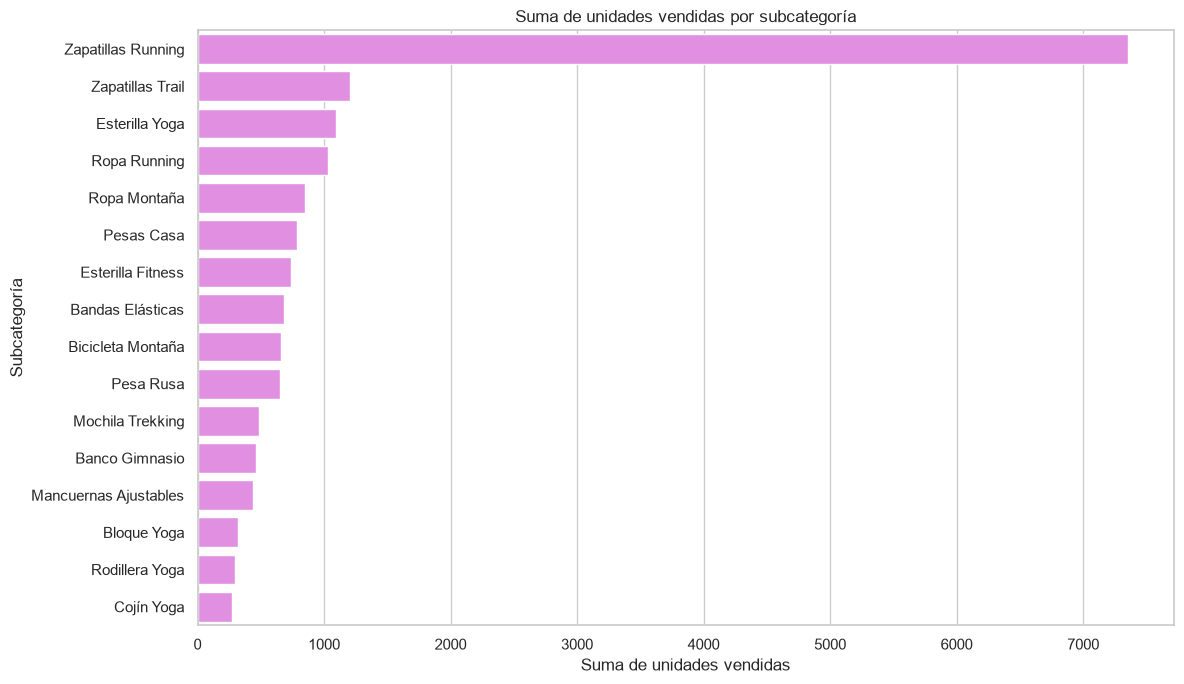

,subcategoria,unidades_vendidas
14,Zapatillas Running,7350
15,Zapatillas Trail,1208
6,Esterilla Yoga,1094
13,Ropa Running,1032
12,Ropa Montaña,852
10,Pesas Casa,788
5,Esterilla Fitness,735
1,Bandas Elásticas,685
2,Bicicleta Montaña,657
9,Pesa Rusa,653


In [19]:
# Gráfico 4: ventas por subcategoría
ventas_subcategoria = (
    df_eda.groupby("subcategoria", as_index=False)["unidades_vendidas"]
    .sum()
    .sort_values("unidades_vendidas", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=ventas_subcategoria,
    x="unidades_vendidas",
    y="subcategoria",
    color="violet",
    ax=ax,
)
ax.set_title("Suma de unidades vendidas por subcategoría")
ax.set_xlabel("Suma de unidades vendidas")
ax.set_ylabel("Subcategoría")
plt.tight_layout()
plt.show()

display(ventas_subcategoria)


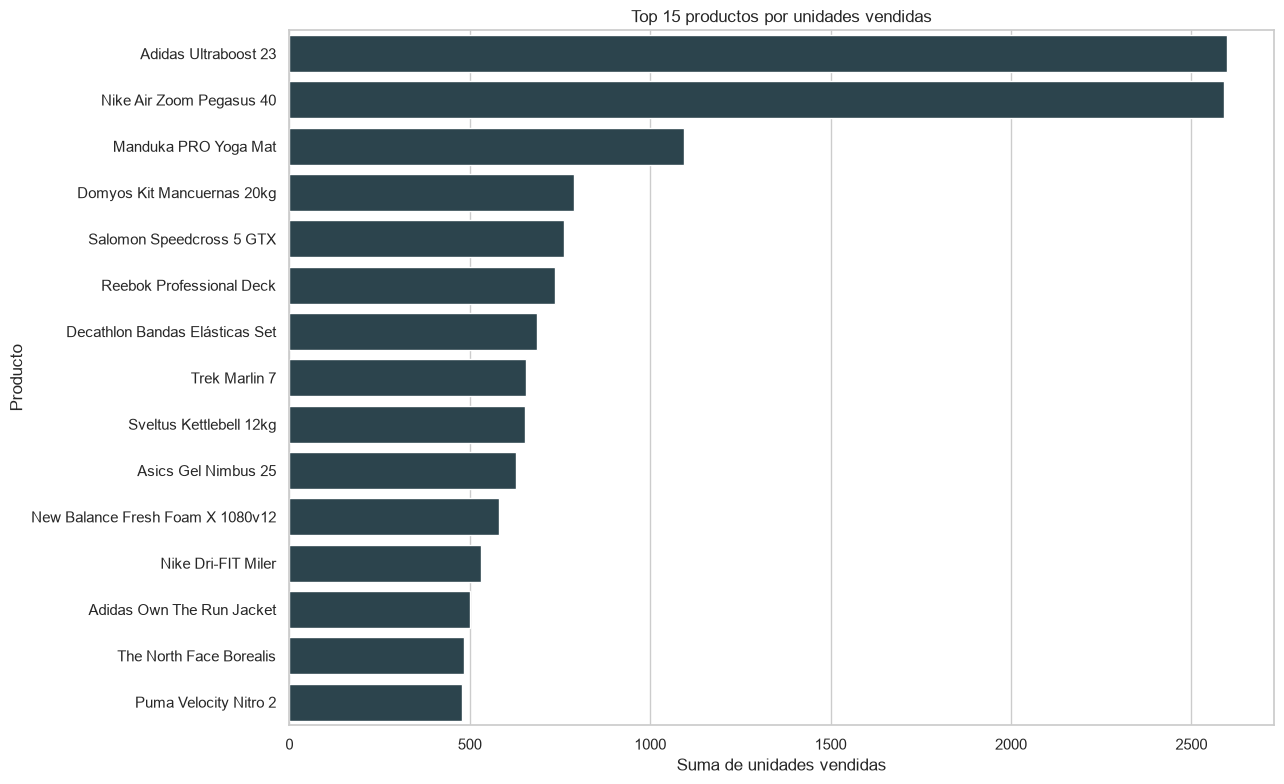

,producto_id,nombre,unidades_vendidas
1,PROD_002,Adidas Ultraboost 23,2599
0,PROD_001,Nike Air Zoom Pegasus 40,2590
20,PROD_021,Manduka PRO Yoga Mat,1094
11,PROD_012,Domyos Kit Mancuernas 20kg,788
14,PROD_015,Salomon Speedcross 5 GTX,760
10,PROD_011,Reebok Professional Deck,735
12,PROD_013,Decathlon Bandas Elásticas Set,685
15,PROD_016,Trek Marlin 7,657
13,PROD_014,Sveltus Kettlebell 12kg,653
2,PROD_003,Asics Gel Nimbus 25,629


In [20]:
# Gráfico 5: top productos por unidades vendidas
n_top = 15
top_productos = (
    df_eda.groupby(["producto_id", "nombre"], as_index=False)["unidades_vendidas"]
    .sum()
    .sort_values("unidades_vendidas", ascending=False)
    .head(n_top)
)

fig, ax = plt.subplots(figsize=(13, 8))
sns.barplot(
    data=top_productos,
    x="unidades_vendidas",
    y="nombre",
    color="#264653",
    ax=ax,
)
ax.set_title(f"Top {n_top} productos por unidades vendidas")
ax.set_xlabel("Suma de unidades vendidas")
ax.set_ylabel("Producto")
plt.tight_layout()
plt.show()

display(top_productos)


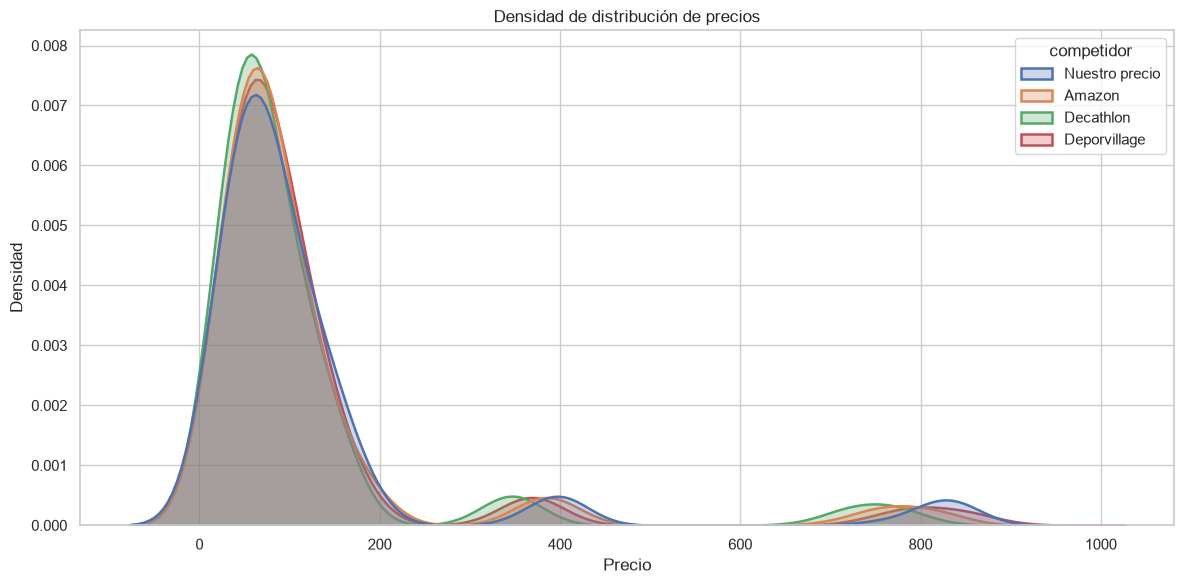

,count,mean,std,min,25%,50%,75%,max
competidor,,,,,,,,
Amazon,3552.0,118.62,156.10,16.85,47.12,73.18,114.34,858.35
Decathlon,3552.0,111.41,148.51,15.45,43.28,66.28,111.17,867.34
Deporvillage,3552.0,118.89,160.22,16.77,47.31,72.70,114.98,932.32
Nuestro precio,3552.0,121.82,164.02,19.00,47.21,71.81,118.22,854.22


In [21]:
# Gráfico 6: densidad de precios propios y de la competencia
columnas_precios = {
    "precio_venta": "Nuestro precio",
    "Amazon": "Amazon",
    "Decathlon": "Decathlon",
    "Deporvillage": "Deporvillage",
}
columnas_disponibles = [columna for columna in columnas_precios if columna in df_eda.columns]

precios = df_eda[columnas_disponibles].rename(columns=columnas_precios).melt(
    var_name="competidor",
    value_name="precio",
).dropna()
precios = precios.loc[precios["precio"] >= 0]

fig, ax = plt.subplots(figsize=(12, 6))
sns.kdeplot(
    data=precios,
    x="precio",
    hue="competidor",
    fill=True,
    common_norm=False,
    alpha=0.28,
    linewidth=1.8,
    ax=ax,
)
ax.set_title("Densidad de distribución de precios")
ax.set_xlabel("Precio")
ax.set_ylabel("Densidad")
plt.tight_layout()
plt.show()

display(precios.groupby("competidor")["precio"].describe().round(2))


## FASE 3: PREPARACIÓN DE DATOS PARA LA MODELIZACIÓN.

a- Creación de variables
   * Identificar patrones: mes (mayores ventas), estar a principio o fin de mes, dia de la semana, si estamos en blackfriday.
   Variables: mes, dia del mes, dia de la semana (laboral o no), fechas convretas (blackfriday, cybermonday)
   Éstas son variables temporales y variables de calendario.

   * Otras variables: descuentos (historicos y los que se pretende)
                      descuento de la competencia (historicos y los que se pretende)
                      

In [22]:
# Creacion de variables temporales y de calendario
# Se trabaja sobre una copia para conservar el dataframe integrado original.
df_model = df.copy()
df_model["fecha"] = pd.to_datetime(df_model["fecha"], errors="coerce")
df_model = df_model.dropna(subset=["fecha"]).copy()

# Calendario oficial de feriados nacionales de Argentina para todos los años observados.
años_observados = range(
    int(df_model["fecha"].dt.year.min()),
    int(df_model["fecha"].dt.year.max()) + 1,
)
feriados_argentina = hdays.Argentina(years=años_observados)
df_model["es_feriado"] = df_model["fecha"].dt.date.map(feriados_argentina).notna()

# Variables basicas de fecha y estacionalidad.
df_model["año"] = df_model["fecha"].dt.year
df_model["mes"] = df_model["fecha"].dt.month
df_model["trimestre"] = df_model["fecha"].dt.quarter
df_model["semana_año"] = df_model["fecha"].dt.isocalendar().week.astype(int)
df_model["dia_año"] = df_model["fecha"].dt.dayofyear
df_model["dia_mes"] = df_model["fecha"].dt.day
df_model["dia_semana"] = df_model["fecha"].dt.dayofweek + 1
df_model["nombre_dia"] = df_model["fecha"].dt.day_name()
df_model["nombre_mes"] = df_model["fecha"].dt.month_name()
df_model["es_fin_semana"] = df_model["fecha"].dt.dayofweek >= 5
# Festivo se interpreta como dia no laborable: fin de semana o feriado oficial.
df_model["es_festivo"] = df_model["es_fin_semana"] | df_model["es_feriado"]
df_model["es_dia_laborable"] = ~df_model["es_festivo"]

# Posicion de la fecha dentro del mes, trimestre y año.
df_model["semana_mes"] = ((df_model["dia_mes"] - 1) // 7 + 1).astype(int)
df_model["es_inicio_mes"] = df_model["dia_mes"] <= 7
df_model["es_fin_mes"] = df_model["fecha"].dt.is_month_end
df_model["es_inicio_trimestre"] = df_model["fecha"].dt.is_quarter_start
df_model["es_fin_trimestre"] = df_model["fecha"].dt.is_quarter_end
df_model["es_inicio_año"] = df_model["fecha"].dt.is_year_start
df_model["es_fin_año"] = df_model["fecha"].dt.is_year_end
df_model["dias_hasta_fin_mes"] = (
    df_model["fecha"].dt.days_in_month - df_model["dia_mes"]
)
df_model["es_quincena"] = df_model["dia_mes"].isin([1, 15])

# Campañas comerciales: Black Friday es el cuarto viernes de noviembre.
noviembre = df_model["fecha"].dt.month.eq(11)
viernes = df_model["fecha"].dt.dayofweek.eq(4)
df_model["es_blackfriday"] = noviembre & viernes & df_model["fecha"].dt.day.between(22, 28)

# Cyber Monday es el lunes inmediatamente posterior a Black Friday.
df_model["es_cyber_monday"] = (
    df_model["fecha"].dt.dayofweek.eq(0)
    & df_model["fecha"].dt.month.eq(11)
    & df_model["fecha"].dt.day.between(23, 29)
)

# Fechas comerciales y festivas con posible impacto en la demanda.
df_model["es_navidad"] = (df_model["fecha"].dt.month == 12) & (df_model["fecha"].dt.day == 25)
df_model["es_año_nuevo"] = (df_model["mes"] == 1) & (df_model["dia_mes"] == 1)
df_model["es_reyes"] = (df_model["mes"] == 1) & (df_model["dia_mes"] == 6)
df_model["es_nochebuena"] = (df_model["mes"] == 12) & (df_model["dia_mes"] == 24)
df_model["es_fin_de_año"] = (df_model["mes"] == 12) & (df_model["dia_mes"] == 31)

# Codificacion ciclica para que enero y diciembre, o domingo y lunes, queden cerca.
df_model["mes_sin"] = np.sin(2 * np.pi * df_model["mes"] / 12)
df_model["mes_cos"] = np.cos(2 * np.pi * df_model["mes"] / 12)
df_model["dia_semana_sin"] = np.sin(2 * np.pi * df_model["dia_semana"] / 7)
df_model["dia_semana_cos"] = np.cos(2 * np.pi * df_model["dia_semana"] / 7)

print(f"Variables temporales creadas: {len(df_model.columns) - len(df.columns)}")
print(f"Feriados argentinos identificados: {int(df_model['es_feriado'].sum())}")
print(f"Black Friday identificados: {int(df_model['es_blackfriday'].sum())}")
print(f"Cyber Monday identificados: {int(df_model['es_cyber_monday'].sum())}")
display(df_model.head())

Variables temporales creadas: 33
Feriados argentinos identificados: 144
Black Friday identificados: 96
Cyber Monday identificados: 96


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_cyber_monday,es_navidad,es_año_nuevo,es_reyes,es_nochebuena,es_fin_de_año,mes_sin,mes_cos,dia_semana_sin,dia_semana_cos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,False,False,False,False,False,False,-0.866025,0.5,0.781831,0.623490
1,2021-10-26,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,8,117.37,938.96,...,False,False,False,False,False,False,-0.866025,0.5,0.974928,-0.222521
2,2021-10-27,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,8,114.27,914.16,...,False,False,False,False,False,False,-0.866025,0.5,0.433884,-0.900969
3,2021-10-28,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,118.14,826.98,...,False,False,False,False,False,False,-0.866025,0.5,-0.433884,-0.900969
4,2021-10-29,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,12,117.23,1406.76,...,False,False,False,False,False,False,-0.866025,0.5,-0.974928,-0.222521


In [23]:
# Creacion de lags y media movil de unidades vendidas
# El agrupamiento por año y producto evita mezclar años o productos distintos.
df_model = df_model.sort_values(["año", "producto_id", "fecha"]).copy()
grupo_anual_producto = df_model.groupby(["año", "producto_id"], sort=False)["unidades_vendidas"]

for lag in range(1, 8):
    df_model[f"unidades_vendidas_lag_{lag}"] = grupo_anual_producto.shift(lag)

# La media movil usa los siete dias anteriores, sin incluir el valor actual.
df_model["unidades_vendidas_media_movil_7"] = (
    grupo_anual_producto
    .apply(lambda serie: serie.shift(1).rolling(window=7, min_periods=7).mean())
    .reset_index(level=[0, 1], drop=True)
)

variables_lags = [
    f"unidades_vendidas_lag_{lag}" for lag in range(1, 8)
] + ["unidades_vendidas_media_movil_7"]

filas_antes_lags = len(df_model)
df_model = df_model.dropna(subset=variables_lags).copy()
df_model[variables_lags] = df_model[variables_lags].astype(float)

print(f"Filas antes de crear lags: {filas_antes_lags:,}")
print(f"Filas eliminadas por historial insuficiente: {filas_antes_lags - len(df_model):,}")
print(f"Filas disponibles para modelizar: {len(df_model):,}")
print(f"Nulos en variables nuevas: {int(df_model[variables_lags].isna().sum().sum())}")
display(df_model[["año", "producto_id", "fecha", "unidades_vendidas"] + variables_lags].head(10))

Filas antes de crear lags: 3,552
Filas eliminadas por historial insuficiente: 672
Filas disponibles para modelizar: 2,880
Nulos en variables nuevas: 0


,año,producto_id,fecha,unidades_vendidas,unidades_vendidas_lag_1,unidades_vendidas_lag_2,unidades_vendidas_lag_3,unidades_vendidas_lag_4,unidades_vendidas_lag_5,unidades_vendidas_lag_6,unidades_vendidas_lag_7,unidades_vendidas_media_movil_7
7,2021,PROD_001,2021-11-01,7,9.0,12.0,12.0,7.0,8.0,8.0,6.0,8.857143
8,2021,PROD_001,2021-11-02,10,7.0,9.0,12.0,12.0,7.0,8.0,8.0,9.000000
9,2021,PROD_001,2021-11-03,11,10.0,7.0,9.0,12.0,12.0,7.0,8.0,9.285714
10,2021,PROD_001,2021-11-04,12,11.0,10.0,7.0,9.0,12.0,12.0,7.0,9.714286
11,2021,PROD_001,2021-11-05,10,12.0,11.0,10.0,7.0,9.0,12.0,12.0,10.428571
12,2021,PROD_001,2021-11-06,10,10.0,12.0,11.0,10.0,7.0,9.0,12.0,10.142857
13,2021,PROD_001,2021-11-07,10,10.0,10.0,12.0,11.0,10.0,7.0,9.0,9.857143
14,2021,PROD_001,2021-11-08,9,10.0,10.0,10.0,12.0,11.0,10.0,7.0,10.000000
15,2021,PROD_001,2021-11-09,11,9.0,10.0,10.0,10.0,12.0,11.0,10.0,10.285714
16,2021,PROD_001,2021-11-10,10,11.0,9.0,10.0,10.0,10.0,12.0,11.0,10.428571


In [24]:
# Verificacion
df.groupby(df["fecha"].dt.year).size().rename_axis("año")

año
2021    888
2022    888
2023    888
2024    888
dtype: int64

### Variables de descuentos

In [25]:
# Creacion de la variable de descuento porcentual
df_model["descuento_porcentaje"] = (
    (df_model["precio_venta"] - df_model["precio_base"])
    / df_model["precio_base"]
    * 100
)

print("Variable creada: descuento_porcentaje")
display(
    df_model[["precio_base", "precio_venta", "descuento_porcentaje"]].head()
)

Variable creada: descuento_porcentaje


,precio_base,precio_venta,descuento_porcentaje
7,115,115.07,0.060870
8,115,116.10,0.956522
9,115,114.58,-0.365217
10,115,112.23,-2.408696
11,115,113.81,-1.034783


### Aplicación de one-hot encoding (codificación one-hot) es una técnica de preprocesamiento en aprendizaje automático que transforma variables categóricas en columnas binarias de ceros y unos.

In [26]:
# Ver variables utilizadas en el modelado
df.info()
# vamos a usar las siguientes variables para el modelado:
#nombre, categoria y subacategoria. Para lo cual hago una copia de ellas así las originales no se pierden.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
 10  Amazon             3552 non-null   float64       
 11  Decathlon          3552 non-null   float64       
 12  Deporvillage       3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(5), int64(2), object(4)


In [27]:
# Copia de las variables categoricas para el modelado
columnas_categoricas = ["nombre", "categoria", "subcategoria"]
columnas_categoricas_h = [f"{columna}_h" for columna in columnas_categoricas]

for columna, columna_h in zip(columnas_categoricas, columnas_categoricas_h):
    df_model[columna_h] = df_model[columna].copy()

# One-hot encoding sobre las copias para conservar las variables originales.
df_model = pd.get_dummies(
    df_model,
    columns=columnas_categoricas_h,
    prefix=columnas_categoricas_h,
    prefix_sep="_",
    dtype=int,
)

columnas_one_hot = [
    columna for columna in df_model.columns
    if any(columna.startswith(f"{columna_h}_") for columna_h in columnas_categoricas_h)
]

print(f"Variables categoricas copiadas: {', '.join(columnas_categoricas_h)}")
print(f"Columnas creadas por one-hot encoding: {len(columnas_one_hot)}")
display(df_model[columnas_one_hot].head())

Variables categoricas copiadas: nombre_h, categoria_h, subcategoria_h
Columnas creadas por one-hot encoding: 44


,nombre_h_Adidas Own The Run Jacket,nombre_h_Adidas Ultraboost 23,nombre_h_Asics Gel Nimbus 25,nombre_h_Bowflex SelectTech 552,nombre_h_Columbia Silver Ridge,nombre_h_Decathlon Bandas Elásticas Set,nombre_h_Domyos BM900,nombre_h_Domyos Kit Mancuernas 20kg,nombre_h_Gaiam Premium Yoga Block,nombre_h_Liforme Yoga Pad,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [28]:
# Ésto es del video
df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']

df = pd.get_dummies(df, columns=['nombre_h', 'categoria_h', 'subcategoria_h'], prefix=['nombre_h', 'categoria_h', 'subcategoria_h'], drop_first=False)

df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,False,False,False,False,False,False,False,False,True,False
1,2021-10-26,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,8,117.37,938.96,...,False,False,False,False,False,False,False,False,True,False
2,2021-10-27,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,8,114.27,914.16,...,False,False,False,False,False,False,False,False,True,False
3,2021-10-28,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,118.14,826.98,...,False,False,False,False,False,False,False,False,True,False
4,2021-10-29,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,12,117.23,1406.76,...,False,False,False,False,False,False,False,False,True,False


In [29]:
from pathlib import Path

base_dir = Path.cwd()
project_dir = base_dir.parent if base_dir.name == "notebooks" else base_dir
processed_dir = project_dir / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

output_path = processed_dir / "df.csv"
df.to_csv(output_path, index=False)
print(f"DataFrame guardado en: {output_path.resolve()}")

DataFrame guardado en: C:\Users\451-9610\Documents\Otros\Cursos\2026\DS4B\Dia_1\ForecastingVentas\data\processed\df.csv


In [30]:
# del video
df.to_csv('../data/processed/df.csv', index=False)
print("DataFrame guardado en ../data/processed/df.csv")

DataFrame guardado en ../data/processed/df.csv


In [31]:
pd.set_option("display.max_columns", None)

In [32]:
df.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos', 'Amazon', 'Decathlon', 'Deporvillage',
       'nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Ultraboost 23',
       'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Bowflex SelectTech 552',
       'nombre_h_Columbia Silver Ridge',
       'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900',
       'nombre_h_Domyos Kit Mancuernas 20kg',
       'nombre_h_Gaiam Premium Yoga Block', 'nombre_h_Liforme Yoga Pad',
       'nombre_h_Lotuscrafts Yoga Bolster', 'nombre_h_Manduka PRO Yoga Mat',
       'nombre_h_Merrell Moab 2 GTX',
       'nombre_h_New Balance Fresh Foam X 1080v12',
       'nombre_h_Nike Air Zoom Pegasus 40', 'nombre_h_Nike Dri-FIT Miler',
       'nombre_h_Puma Velocity Nitro 2', 'nombre_h_Quechua MH500',
       'nombre_h_Reebok Floatride Energy 5',
       'nombre_h_Reebok Professional Deck',
       'nombr

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 57 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   fecha                                      3552 non-null   datetime64[ns]
 1   producto_id                                3552 non-null   object        
 2   nombre                                     3552 non-null   object        
 3   categoria                                  3552 non-null   object        
 4   subcategoria                               3552 non-null   object        
 5   precio_base                                3552 non-null   int64         
 6   es_estrella                                3552 non-null   bool          
 7   unidades_vendidas                          3552 non-null   int64         
 8   precio_venta                               3552 non-null   float64       
 9   ingresos           

In [34]:
pd.set_option("display.max_seq_items", None)

# Ahora df.columns se mostrará completo
df.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos', 'Amazon', 'Decathlon', 'Deporvillage',
       'nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Ultraboost 23',
       'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Bowflex SelectTech 552',
       'nombre_h_Columbia Silver Ridge',
       'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900',
       'nombre_h_Domyos Kit Mancuernas 20kg',
       'nombre_h_Gaiam Premium Yoga Block', 'nombre_h_Liforme Yoga Pad',
       'nombre_h_Lotuscrafts Yoga Bolster', 'nombre_h_Manduka PRO Yoga Mat',
       'nombre_h_Merrell Moab 2 GTX',
       'nombre_h_New Balance Fresh Foam X 1080v12',
       'nombre_h_Nike Air Zoom Pegasus 40', 'nombre_h_Nike Dri-FIT Miler',
       'nombre_h_Puma Velocity Nitro 2', 'nombre_h_Quechua MH500',
       'nombre_h_Reebok Floatride Energy 5',
       'nombre_h_Reebok Professional Deck',
       'nombr

In [35]:
años_df = pd.to_datetime(df["fecha"]).dt.year

train_df = df.loc[años_df.between(2021, 2023)].copy()
validation_df = df.loc[años_df.eq(2024)].copy()

print(f"Registros en train_df (2021-2023): {len(train_df):,}")
print(f"Registros en validation_df (2024): {len(validation_df):,}")

Registros en train_df (2021-2023): 2,664
Registros en validation_df (2024): 888


### Creación y evaluación del modelo.
Se va a tomar 3 años para entrenar y el cuarto para validar

In [36]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Se excluyen las columnas indicadas y cualquier variable object; se conservan
# variables numéricas y booleanas, que HistGradientBoostingRegressor admite.
columnas_excluidas = {"fecha", "ingresos", "unidades_vendidas"}
columnas_predictoras = [
    columna
    for columna in train_df.columns
    if columna not in columnas_excluidas
    and (
        pd.api.types.is_numeric_dtype(train_df[columna])
        or pd.api.types.is_bool_dtype(train_df[columna])
    )
]

X_train = train_df[columnas_predictoras]
y_train = train_df["unidades_vendidas"]
X_validation = validation_df.reindex(columns=columnas_predictoras)
y_validation = validation_df["unidades_vendidas"]

modelo_hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_depth=5,
    max_leaf_nodes=15,
    min_samples_leaf=30,
    l2_regularization=5.0,
    early_stopping=False,
    random_state=42,
)
modelo_hgb.fit(X_train, y_train)
predicciones_hgb = modelo_hgb.predict(X_validation)

# Baseline naive: la media observada en el conjunto de entrenamiento.
predicciones_media = np.full(len(y_validation), y_train.mean())

def calcular_metricas_forecasting(y_real, y_predicho):
    y_real = np.asarray(y_real, dtype=float)
    y_predicho = np.asarray(y_predicho, dtype=float)
    errores_absolutos = np.abs(y_real - y_predicho)
    denominador_smape = np.abs(y_real) + np.abs(y_predicho)
    valores_smape = np.divide(
        2 * errores_absolutos,
        denominador_smape,
        out=np.zeros_like(errores_absolutos),
        where=denominador_smape != 0,
    )
    mascara_mape = y_real != 0

    return {
        "MAE": mean_absolute_error(y_real, y_predicho),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_predicho)),
        "MAPE (%)": (
            np.mean(errores_absolutos[mascara_mape] / np.abs(y_real[mascara_mape])) * 100
            if mascara_mape.any()
            else np.nan
        ),
        "sMAPE (%)": np.mean(valores_smape) * 100,
        "WAPE (%)": (
            np.sum(errores_absolutos) / np.sum(np.abs(y_real)) * 100
            if np.sum(np.abs(y_real)) != 0
            else np.nan
        ),
        "R2": r2_score(y_real, y_predicho),
    }

resultados_modelos = pd.DataFrame(
    {
        "HistGradientBoostingRegressor": calcular_metricas_forecasting(
            y_validation, predicciones_hgb
        ),
        "Baseline media": calcular_metricas_forecasting(
            y_validation, predicciones_media
        ),
    }
).T

print(f"Predictoras utilizadas ({len(columnas_predictoras)}): {columnas_predictoras}")
print(f"Media de unidades_vendidas en train: {y_train.mean():.4f}")
display(resultados_modelos.round(4))

Predictoras utilizadas (50): ['precio_base', 'es_estrella', 'precio_venta', 'Amazon', 'Decathlon', 'Deporvillage', 'nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Ultraboost 23', 'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Bowflex SelectTech 552', 'nombre_h_Columbia Silver Ridge', 'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900', 'nombre_h_Domyos Kit Mancuernas 20kg', 'nombre_h_Gaiam Premium Yoga Block', 'nombre_h_Liforme Yoga Pad', 'nombre_h_Lotuscrafts Yoga Bolster', 'nombre_h_Manduka PRO Yoga Mat', 'nombre_h_Merrell Moab 2 GTX', 'nombre_h_New Balance Fresh Foam X 1080v12', 'nombre_h_Nike Air Zoom Pegasus 40', 'nombre_h_Nike Dri-FIT Miler', 'nombre_h_Puma Velocity Nitro 2', 'nombre_h_Quechua MH500', 'nombre_h_Reebok Floatride Energy 5', 'nombre_h_Reebok Professional Deck', 'nombre_h_Salomon Speedcross 5 GTX', 'nombre_h_Sveltus Kettlebell 12kg', 'nombre_h_The North Face Borealis', 'nombre_h_Trek Marlin 7', 'categoria_h_Fitness', 'categoria_h_Outdoor', 'categoria

,MAE,RMSE,MAPE (%),sMAPE (%),WAPE (%),R2
HistGradientBoostingRegressor,1.6066,2.8276,35.5905,31.2115,32.1831,0.7952
Baseline media,3.3470,6.2498,86.5066,60.2604,67.0450,-0.0006


Predicciones generadas: 210 para 7 productos estrella.


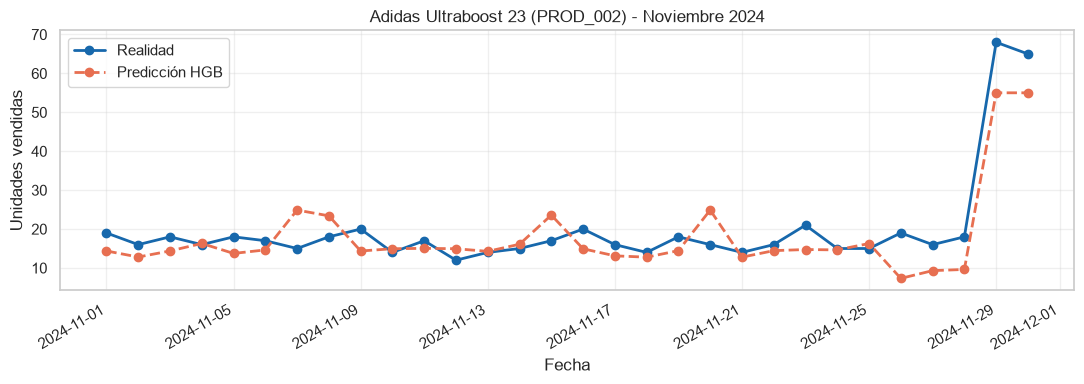

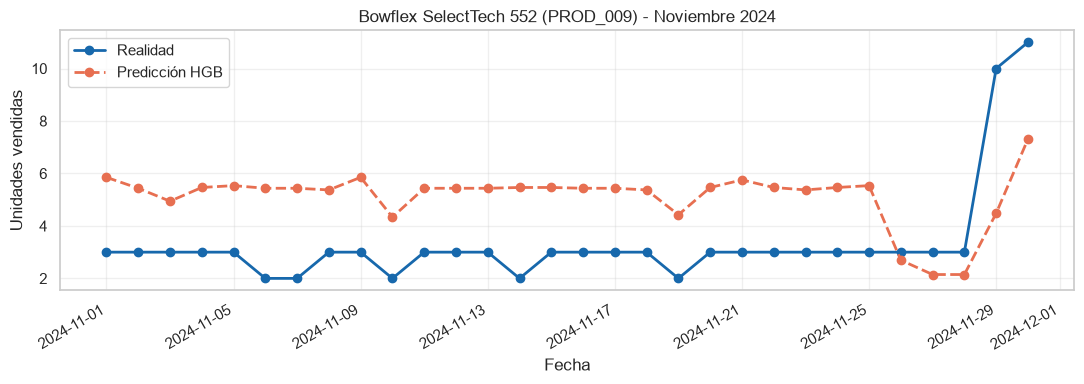

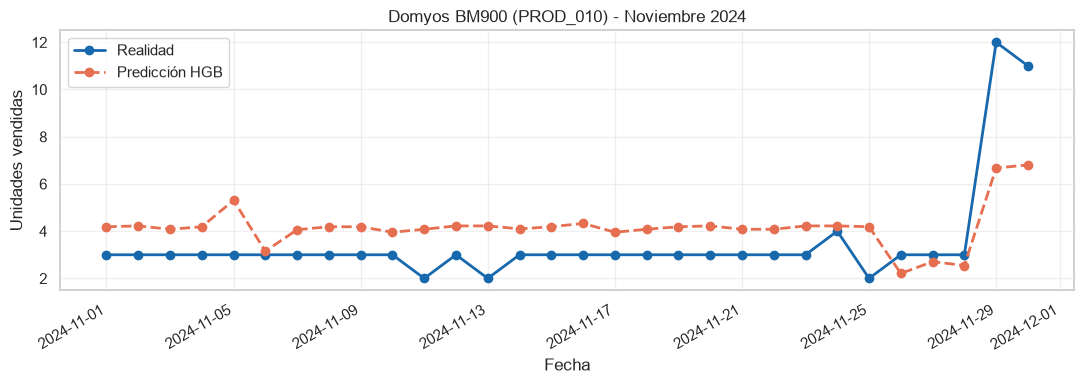

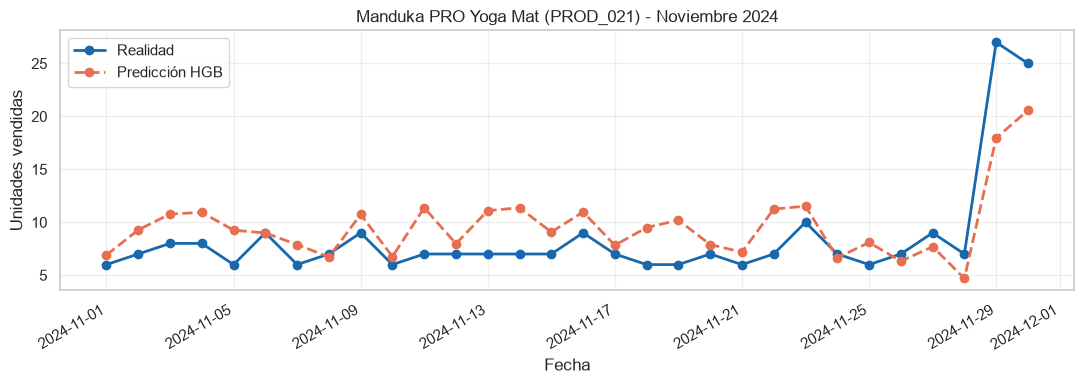

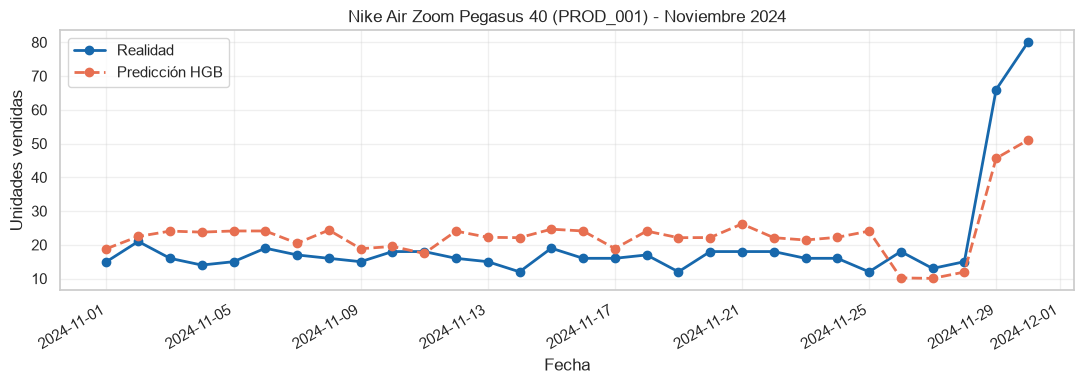

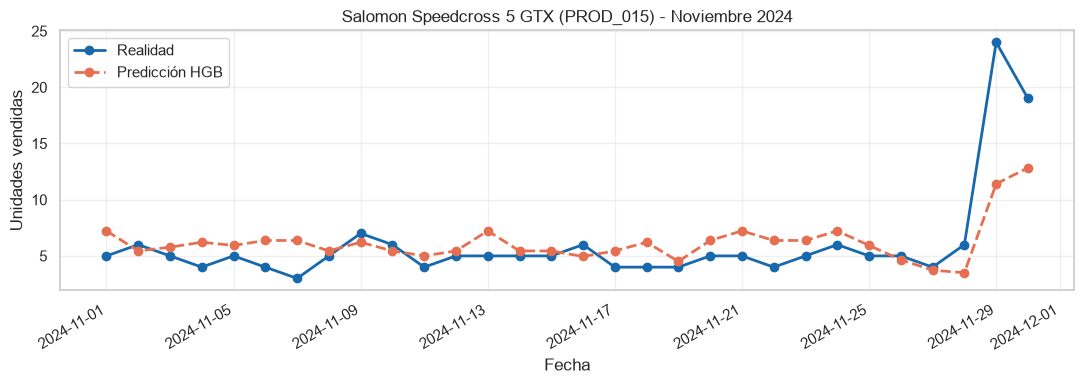

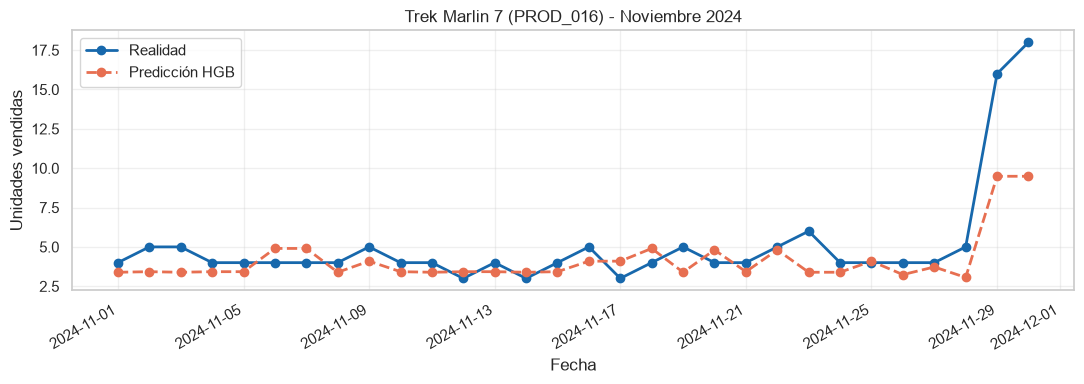

In [37]:
# Predicciones y comparación con la realidad para noviembre de 2024.
df_noviembre = df.copy()
df_noviembre["fecha"] = pd.to_datetime(df_noviembre["fecha"], errors="coerce")
df_noviembre = df_noviembre.loc[
    df_noviembre["fecha"].dt.to_period("M").eq("2024-11")
    & df_noviembre["es_estrella"].eq(True)
].copy()

productos_estrella_noviembre = (
    df_noviembre[["producto_id", "nombre"]]
    .drop_duplicates()
    .sort_values(["nombre", "producto_id"])
)
if len(productos_estrella_noviembre) != 7:
    raise ValueError(
        f"Se esperaban 7 productos estrella en noviembre de 2024; "
        f"se encontraron {len(productos_estrella_noviembre)}."
    )

X_noviembre = df_noviembre.reindex(columns=columnas_predictoras)
df_noviembre["prediccion_unidades"] = modelo_hgb.predict(X_noviembre)
predicciones_noviembre = df_noviembre[
    ["fecha", "producto_id", "nombre", "unidades_vendidas", "prediccion_unidades"]
].sort_values(["nombre", "fecha"])

print(
    f"Predicciones generadas: {len(predicciones_noviembre)} "
    f"para {len(productos_estrella_noviembre)} productos estrella."
)

for _, producto in productos_estrella_noviembre.iterrows():
    datos_producto = predicciones_noviembre.loc[
        predicciones_noviembre["producto_id"].eq(producto["producto_id"])
    ].sort_values("fecha")

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(
        datos_producto["fecha"],
        datos_producto["unidades_vendidas"],
        marker="o",
        linewidth=2,
        label="Realidad",
        color="#1768ac",
    )
    ax.plot(
        datos_producto["fecha"],
        datos_producto["prediccion_unidades"],
        marker="o",
        linewidth=2,
        linestyle="--",
        label="Predicción HGB",
        color="#e76f51",
    )
    ax.set_title(f"{producto['nombre']} ({producto['producto_id']}) - Noviembre 2024")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Unidades vendidas")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


In [38]:
errores_productos_estrella = predicciones_noviembre.copy()
errores_productos_estrella["error_absoluto"] = (
    errores_productos_estrella["unidades_vendidas"]
    - errores_productos_estrella["prediccion_unidades"]
).abs()

mae_por_producto_estrella = (
    errores_productos_estrella.groupby(["producto_id", "nombre"], as_index=False)
    .agg(
        MAE=("error_absoluto", "mean"),
        observaciones=("error_absoluto", "count"),
    )
    .sort_values("MAE")
)

display(mae_por_producto_estrella.round({"MAE": 2}))

,producto_id,nombre,MAE,observaciones
5,PROD_016,Trek Marlin 7,1.29,30
3,PROD_010,Domyos BM900,1.40,30
4,PROD_015,Salomon Speedcross 5 GTX,1.85,30
6,PROD_021,Manduka PRO Yoga Mat,2.37,30
2,PROD_009,Bowflex SelectTech 552,2.53,30
1,PROD_002,Adidas Ultraboost 23,4.50,30
0,PROD_001,Nike Air Zoom Pegasus 40,7.25,30


,observaciones,MAE,RMSE,MAPE (%),sMAPE (%),WAPE (%),R2
periodo,,,,,,,
1-10 nov,70,2.47,3.34,39.91,31.24,30.92,0.68
11-20 nov,70,2.62,3.55,42.29,32.85,34.65,0.59
21-30 nov,70,3.99,6.33,33.74,33.38,31.22,0.83


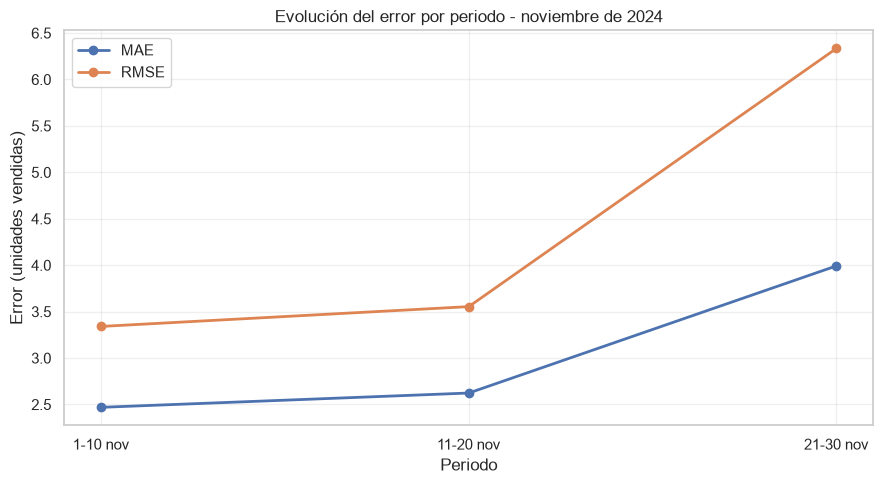

In [39]:
predicciones_por_periodo = predicciones_noviembre.copy()
predicciones_por_periodo["periodo"] = pd.cut(
    predicciones_por_periodo["fecha"].dt.day,
    bins=[0, 10, 20, 31],
    labels=["1-10 nov", "11-20 nov", "21-30 nov"],
    include_lowest=True,
)

resultados_periodos = []
for periodo, datos_periodo in predicciones_por_periodo.groupby(
    "periodo", observed=True, sort=True
):
    metricas_periodo = calcular_metricas_forecasting(
        datos_periodo["unidades_vendidas"],
        datos_periodo["prediccion_unidades"],
    )
    resultados_periodos.append(
        {
            "periodo": periodo,
            "observaciones": len(datos_periodo),
            **metricas_periodo,
        }
    )

metricas_por_periodo = pd.DataFrame(resultados_periodos).set_index("periodo")
display(metricas_por_periodo.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
for metrica in ["MAE", "RMSE"]:
    ax.plot(
        metricas_por_periodo.index.astype(str),
        metricas_por_periodo[metrica],
        marker="o",
        linewidth=2,
        label=metrica,
    )
ax.set_title("Evolución del error por periodo - noviembre de 2024")
ax.set_xlabel("Periodo")
ax.set_ylabel("Error (unidades vendidas)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

periodo,1-10 nov,11-20 nov,21-30 nov
nombre,,,
Adidas Ultraboost 23,4.02,3.45,6.04
Bowflex SelectTech 552,2.67,2.54,2.38
Domyos BM900,1.15,1.36,1.69
Manduka PRO Yoga Mat,1.68,2.73,2.72
Nike Air Zoom Pegasus 40,5.45,6.39,9.92
Salomon Speedcross 5 GTX,1.42,1.11,3.00
Trek Marlin 7,0.88,0.79,2.21


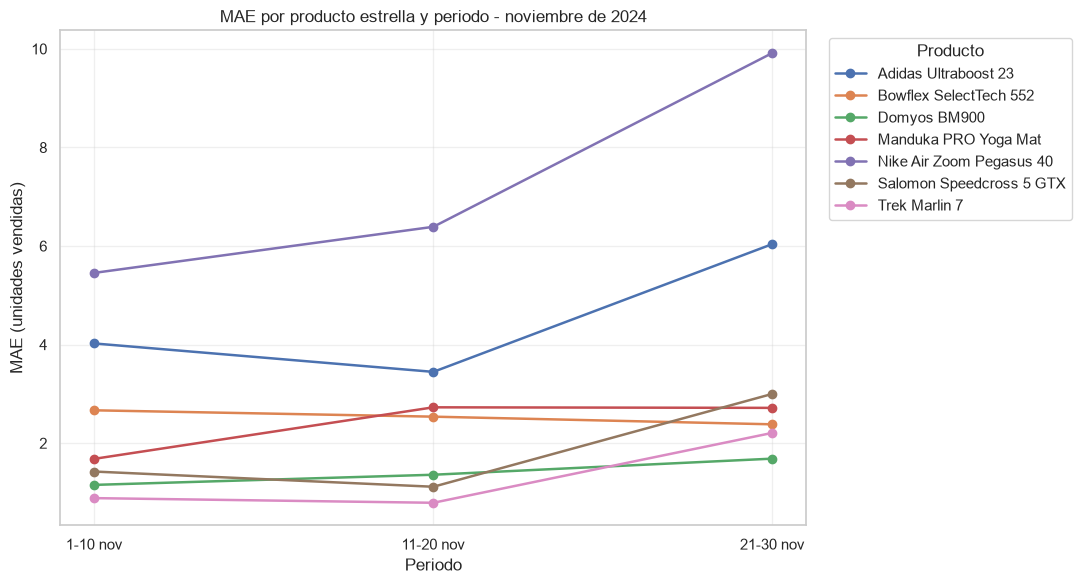

In [40]:
errores_por_producto_periodo = predicciones_por_periodo.copy()
errores_por_producto_periodo["error_absoluto"] = (
    errores_por_producto_periodo["unidades_vendidas"]
    - errores_por_producto_periodo["prediccion_unidades"]
).abs()

mae_producto_periodo = (
    errores_por_producto_periodo.groupby(
        ["periodo", "producto_id", "nombre"],
        as_index=False,
        observed=True,
    )
    .agg(MAE=("error_absoluto", "mean"))
    .sort_values(["periodo", "nombre"])
)
display(mae_producto_periodo.pivot(
    index="nombre",
    columns="periodo",
    values="MAE",
).round(2))

fig, ax = plt.subplots(figsize=(11, 6))
for (producto_id, nombre), datos_producto in mae_producto_periodo.groupby(
    ["producto_id", "nombre"], sort=False
):
    ax.plot(
        datos_producto["periodo"].astype(str),
        datos_producto["MAE"],
        marker="o",
        linewidth=1.8,
        label=nombre,
    )
ax.set_title("MAE por producto estrella y periodo - noviembre de 2024")
ax.set_xlabel("Periodo")
ax.set_ylabel("MAE (unidades vendidas)")
ax.legend(title="Producto", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

Productos incluidos: 24


,producto_id,nombre,unidades_vendidas,prediccion_unidades
146,PROD_001,Nike Air Zoom Pegasus 40,66,45.63
294,PROD_002,Adidas Ultraboost 23,68,55.01
442,PROD_003,Asics Gel Nimbus 25,18,8.36
590,PROD_004,New Balance Fresh Foam X 1080v12,14,8.94
738,PROD_005,Nike Dri-FIT Miler,14,8.53
886,PROD_006,Adidas Own The Run Jacket,12,7.88
1034,PROD_007,Puma Velocity Nitro 2,13,9.57
1182,PROD_008,Reebok Floatride Energy 5,12,7.95
1330,PROD_009,Bowflex SelectTech 552,10,4.48
1478,PROD_010,Domyos BM900,12,6.68


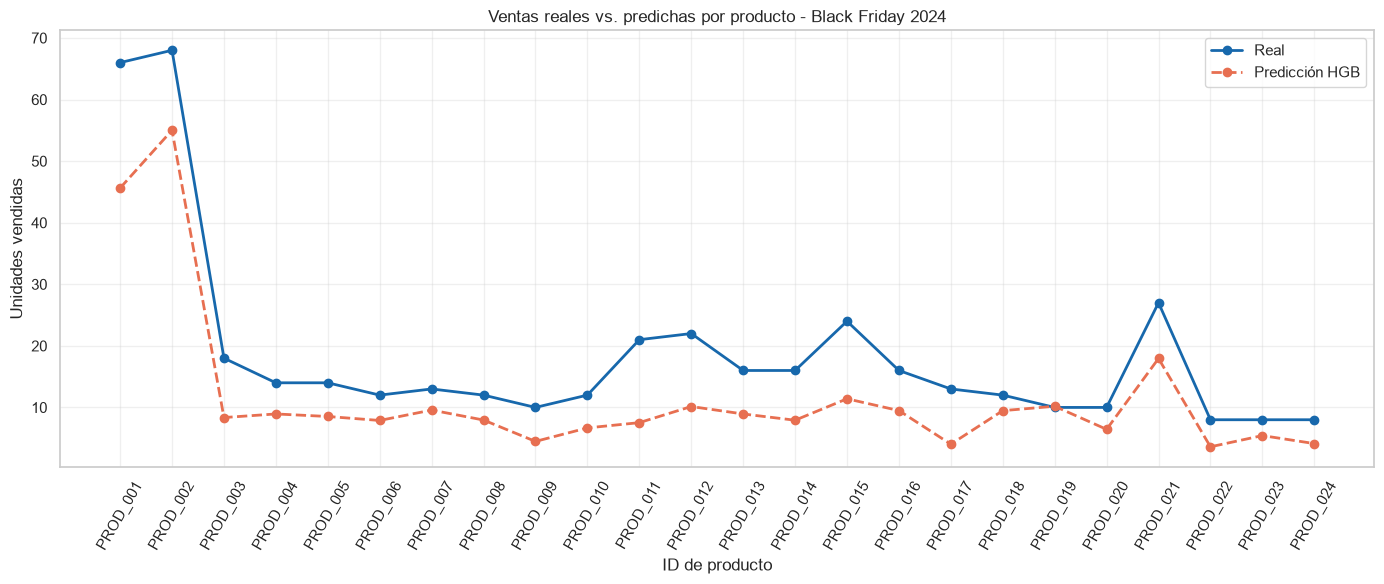

In [41]:
# Real vs. predicho para Black Friday de 2024 (viernes 29 de noviembre).
fecha_black_friday = pd.Timestamp("2024-11-29")
fechas_df = pd.to_datetime(df["fecha"], errors="coerce")
datos_black_friday = df.loc[fechas_df.eq(fecha_black_friday)].copy()

if datos_black_friday.empty:
    raise ValueError(f"No hay datos para Black Friday: {fecha_black_friday.date()}.")
if datos_black_friday["producto_id"].duplicated().any():
    raise ValueError("Hay más de un registro por producto en Black Friday.")

datos_black_friday["prediccion_unidades"] = modelo_hgb.predict(
    datos_black_friday.reindex(columns=columnas_predictoras)
)
datos_black_friday = datos_black_friday.sort_values("producto_id")

print(f"Productos incluidos: {datos_black_friday['producto_id'].nunique()}")
display(
    datos_black_friday[
        ["producto_id", "nombre", "unidades_vendidas", "prediccion_unidades"]
    ].round({"prediccion_unidades": 2})
)

fig, ax = plt.subplots(figsize=(14, 6))
ids_productos = datos_black_friday["producto_id"].astype(str)
ax.plot(
    ids_productos,
    datos_black_friday["unidades_vendidas"],
    marker="o",
    linewidth=2,
    label="Real",
    color="#1768ac",
)
ax.plot(
    ids_productos,
    datos_black_friday["prediccion_unidades"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Predicción HGB",
    color="#e76f51",
)
ax.set_title("Ventas reales vs. predichas por producto - Black Friday 2024")
ax.set_xlabel("ID de producto")
ax.set_ylabel("Unidades vendidas")
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis="x", rotation=60)
fig.tight_layout()
plt.show()

In [42]:
## Re entrenamiento del modelo con datos hasta noviembre de 2024 y predicción para diciembre de 2024.
#from sklearn.ensemble import HistGradientBoostingRegressor
#from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Selección de variables predictoras, excluyendo fecha, ingresos y tipo de variable object.
#excluir = ['fecha', 'ingresos', 'unidades_vendidas', 'nombre', 'producto_id', 'categoria', 'subcategoria']
#x_full = df.drop(columns=[col for col in excluir if col in df.columns] + [col for col in df.columns if df[col].dtype == 'object'])
#y_full = df['unidades_vendidas']

# Entrenamiento del modelo final
#modelo_final = HistGradientBoostingRegressor(
 #   learning_rate=0.05,
 #   max_iter=400,
 #   max_depth=7,
 #   l2_regularization=1.0,
 #   random_state=42
#)
#modelo_final.fit(x_full, y_full)

#print("Modelo final entrenado con datos hasta noviembre de 2024.")

In [43]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# 1. Asegurar la conversión de fecha indicando formato día primero si aplica
df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True).dt.floor('D')

# Impresión de diagnóstico para verificar el rango real
min_fecha = df['fecha'].min()
max_fecha = df['fecha'].max()
print(f"Rango real de fechas en el dataset: {min_fecha.strftime('%Y-%m-%d')} a {max_fecha.strftime('%Y-%m-%d')}")

# 2. Definir dinámicamente el último mes presente en el DataFrame como 'Test'
ultimo_ano = max_fecha.year
ultimo_mes = max_fecha.month

# Train: Todo lo anterior al último mes detectado
df_train = df[df['fecha'] < f"{ultimo_ano}-{ultimo_mes:02d}-01"].copy()

# Test: El último mes completo/disponible en el dataset
df_test = df[(df['fecha'].dt.year == ultimo_ano) & (df['fecha'].dt.month == ultimo_mes)].copy()

print(f"Registros en Train (hasta {ultimo_mes-1 if ultimo_mes > 1 else 12}/{ultimo_ano if ultimo_mes > 1 else ultimo_ano-1}): {len(df_train)}")
print(f"Registros en Test (Mes {ultimo_mes}/{ultimo_ano}): {len(df_test)}")

# 3. Preparación de Features
excluir = ['fecha', 'ingresos', 'unidades_vendidas', 'nombre', 'producto_id', 'categoria', 'subcategoria']

cols_object = df.select_dtypes(include=['object', 'string']).columns
for col in cols_object:
    if col not in excluir:
        df_train[col] = df_train[col].astype('category')
        df_test[col] = df_test[col].astype('category')

features = [col for col in df_train.columns if col not in excluir]

X_train = df_train[features]
y_train = df_train['unidades_vendidas']

X_test = df_test[features]
y_test = df_test['unidades_vendidas']

categorical_features = [col for col in features if df_train[col].dtype.name == 'category']

# 4. Entrenamiento
modelo_final = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    categorical_features=categorical_features,
    random_state=42
)

modelo_final.fit(X_train, y_train)

# 5. Predicción y Métricas
y_pred_test = modelo_final.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_test)
rmse = root_mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"\n--- Resultados de Predicción para {ultimo_mes:02d}/{ultimo_ano} ---")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

Rango real de fechas en el dataset: 2021-10-25 a 2024-11-30
Registros en Train (hasta 10/2024): 2832
Registros en Test (Mes 11/2024): 720

--- Resultados de Predicción para 11/2024 ---
MAE:  1.4011
RMSE: 2.4156
R²:   0.8697


In [44]:
import os
import joblib

# 1. Definir la ruta apuntando a la carpeta 'models' en la raíz del proyecto
ruta_carpeta_models = os.path.join("..", "models")

# 2. Asegurar que exista la carpeta 'models' en la raíz
os.makedirs(ruta_carpeta_models, exist_ok=True)

# 3. Ruta completa del archivo .joblib
ruta_modelo = os.path.join(ruta_carpeta_models, "modelo_final.joblib")

# 4. Guardar el modelo
joblib.dump(modelo_final, ruta_modelo)

print(f"Modelo guardado exitosamente en: {os.path.abspath(ruta_modelo)}")

Modelo guardado exitosamente en: c:\Users\451-9610\Documents\Otros\Cursos\2026\DS4B\Dia_1\ForecastingVentas\models\modelo_final.joblib


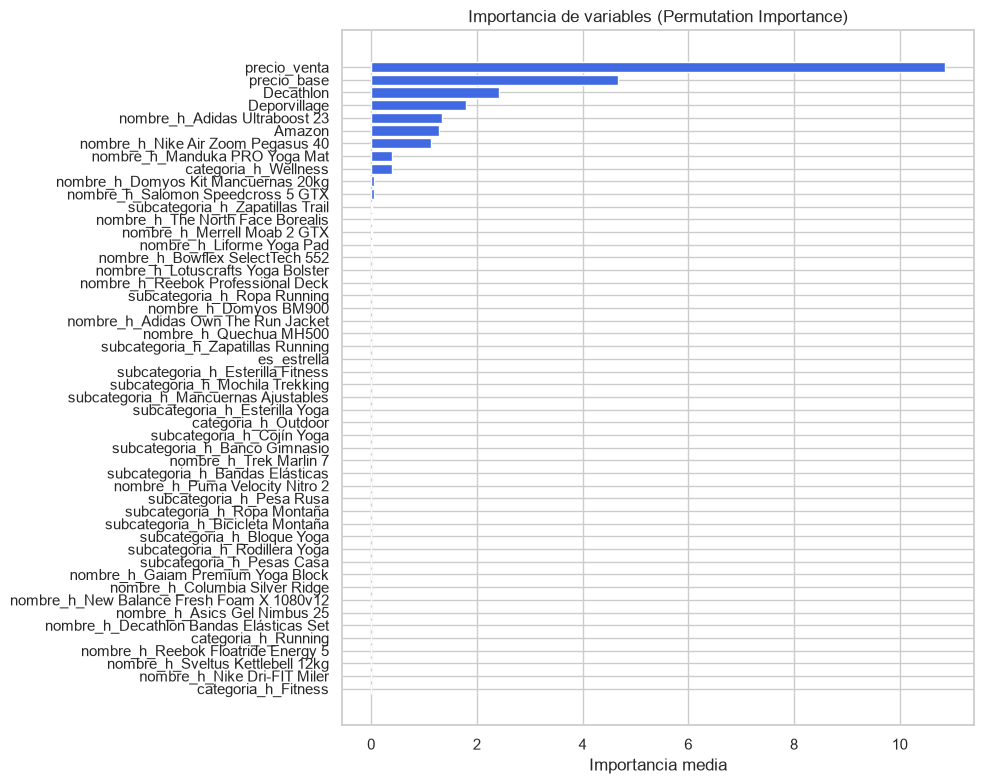

In [45]:
# Importancia de variables con permutation importance y guardado del modelo final[cite: 3]
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Calcular permutation importance[cite: 3]
result = permutation_importance(modelo_final, X_test, y_test, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')
importancias = result.importances_mean
features = X_test.columns

# Crear DataFrame de importancias y ordenar[cite: 3]
importancias_df = pd.DataFrame({'feature': features, 'importance': importancias})
importancias_df = importancias_df.sort_values(by='importance', ascending=False)

# Gráfico de barras horizontales[cite: 3]
plt.figure(figsize=(10,8))
plt.barh(importancias_df['feature'], importancias_df['importance'], color='royalblue')
plt.gca().invert_yaxis()
plt.title('Importancia de variables (Permutation Importance)')
plt.xlabel('Importancia media')
plt.tight_layout()
plt.show()